# Домашнее задание по NLP

## Составление словарей для классификации по тональности

В этом ноутбуке решаются обе части задания:

1. Предобработка отзывов, обучение `word2vec`, проверка стандартных тестов и визуализации
2. Построение лексического графа и распространение меток для получения доменно-специфического словаря тональности

## План решения

Сначала загружаем отзывы и оставляем только валидные тексты с оценками. Затем разбиваем отзывы на предложения, лемматизируем слова и формируем корпус предложений.

После этого обучаем модель `word2vec` и используем её для трёх стандартных проверок:
- поиск ближайших слов
- аналогии
- поиск лишнего слова

Далее строим две визуализации:
- `TSNE` для наиболее частотных слов
- проекцию названий банков в пространство из двух осей: `'плохо' - 'хорошо'` и `'медленно' - 'быстро'`

Во второй части по графу близости слов запускается распространение меток, чтобы расширить набор позитивных и негативных слов.

## Импорт библиотек

Подключение библиотек для работы с данными, лемматизации, обучения эмбеддингов, визуализации и распространения меток представлено ниже.

In [1]:
%pip install numpy pandas matplotlib gensim pymorphy3 scikit-learn tqdm nltk


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import bz2
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from pymorphy3 import MorphAnalyzer
from sklearn.manifold import TSNE
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_colwidth', 120)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Misha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Misha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Загрузка данных

В исходном архиве находятся отзывы о банках. Оставляем только тексты, которые прошли проверку и содержат непустой текст. Дополнительно сохраняем рейтинг, чтобы при желании можно было сравнивать распределение позитивных и негативных отзывов.

In [3]:
responses = []

with bz2.BZ2File('banki_responses.json.bz2', 'r') as file:
    for row in tqdm(file):
        response = json.loads(row)
        if not response['rating_not_checked'] and len(response['text'].split()) > 0:
            responses.append(response)

len(responses)

0it [00:00, ?it/s]

153499

In [4]:
df = pd.DataFrame(responses)
df[['bank_name', 'rating_grade', 'title', 'text']].head()

,bank_name,rating_grade,title,text
0,Бинбанк,NaN,Жалоба,"Добрый день! Я не являюсь клиентом банка и поручителем по кредитному договору, а также не являюсь каким-либо другим ..."
1,Сбербанк России,NaN,Не могу пользоваться услугой Сбербанк он-лайн,"Доброго дня! Являюсь держателем зарплатной карты , выданной Сбербанком России. В 2008 году сменила фамилию, предоста..."
2,Бинбанк,NaN,Двойное списание за один товар.,"Здравствуйте! Дублирую свое заявление от 03.06.2015 в ДО ""Можайский"". 02.06.2015 мною, по моей дебетовой карте был..."
3,Сбербанк России,NaN,Меняют проценты комиссии не предупредив и не известив клиентов!!,"Добрый день!! Я открыл расчетный счет в СберБанке, как Юр. лицо.. Все было бы хорошо если бы не одно НО..... По дог..."
4,ОТП Банк,NaN,Верните денежные средства за страховку,"04.03.2015 г. взяла кредит в вашем банке, заявленная мною сумма была 200 т. рублей и на 1 год. Менеджер же сделала с..."


## Первичный анализ данных

Для понимания общей структуры выборки рассмотрим набор банков и распределение рейтингов.

In [5]:
df['rating_grade'].value_counts(dropna=False).sort_index()

rating_grade
1.0    47387
2.0    13509
3.0     9261
4.0     3788
5.0    14713
NaN    64841
Name: count, dtype: int64

In [6]:
df['text_len'] = df['text'].str.split().str.len()
df['text_len'].describe()

count    153499.000000
mean        237.062743
std         201.430014
min           1.000000
25%         111.000000
50%         182.000000
75%         295.000000
max        5000.000000
Name: text_len, dtype: float64

## Разбиение на предложения и лемматизация

Для обучения `word2vec` рассмотрим набор предложений. Каждое предложение преобразуем в список лемм:
- приводим к нижнему регистру
- оставляем только русские слова
- лемматизируем через `pymorphy2`
- удаляем слишком короткие токены

Такой формат подходит и для обучения эмбеддингов, и для дальнейшего построения графа слов.

In [7]:
morph = MorphAnalyzer()

def split_to_sentences(text):
    return nltk.sent_tokenize(text, language='russian')

def tokenize(text):
    return re.findall(r'[а-яё]+', text.lower())

def lemmatize_tokens(tokens):
    lemmas = []
    for token in tokens:
        if len(token) >= 2:
            lemma = morph.parse(token)[0].normal_form
            lemmas.append(lemma)
    return lemmas

def preprocess_sentence(sentence):
    tokens = tokenize(sentence)
    lemmas = lemmatize_tokens(tokens)
    return lemmas

sentences = []

for text in tqdm(df['text'].astype(str)):
    for sentence in split_to_sentences(text):
        lemmas = preprocess_sentence(sentence)
        if len(lemmas) >= 3:
            sentences.append(lemmas)

len(sentences)

  0%|          | 0/153499 [00:00<?, ?it/s]

2264488

In [8]:
sentences[:5]

[['не',
  'являться',
  'клиент',
  'банк',
  'поручитель',
  'по',
  'кредитный',
  'договор',
  'также',
  'не',
  'являться',
  'какой',
  'либо',
  'другой',
  'лицо',
  'письменно',
  'оформить',
  'отношение',
  'банк',
  'по',
  'повод',
  'урегулирование',
  'чей',
  'либо',
  'задолженность'],
 ['начинать',
  'март',
  'год',
  'начать',
  'приходить',
  'бесконечный',
  'письмо',
  'из',
  'ооо',
  'прить',
  'коллект',
  'на',
  'мой',
  'адрес',
  'город',
  'москва',
  'уваровский',
  'переулок',
  'дом',
  'квартира',
  'угроза',
  'возбуждение',
  'уголовный',
  'дело',
  'отношение',
  'гражданин',
  'филиппов',
  'эдуард',
  'владимирович',
  'который',
  'уклоняться',
  'от',
  'уплата',
  'взять',
  'они',
  'кредит',
  'договор',
  'от',
  'год',
  'договор',
  'от',
  'год'],
 ['с',
  'весь',
  'ответственность',
  'хотеть',
  'вы',
  'заверить',
  'что',
  'вышеуказанный',
  'гражданин',
  'который',
  'вы',
  'разыскивать',
  'я',
  'не',
  'знак',
  'никогда',
 

## Частотный словарь

Перед обучением модели рассмотрим слова, встречающиеся чаще всего. Позже это поможет выбрать список слов для визуализации и стартовые наборы для распространения меток.

In [9]:
word_counts = Counter()

for sentence in sentences:
    word_counts.update(sentence)

freq_df = pd.DataFrame(word_counts.most_common(30), columns=['word', 'count'])
freq_df

,word,count
0,не,850224
1,на,707240
2,банк,665549
3,что,661920
4,я,544622
5,быть,419341
6,по,372359
7,карта,333640
8,это,306331
9,мой,238025


## Обучение модели `word2vec`

Обучаем модель на лемматизированных предложениях. Значения параметров можно менять, но для такой задачи достаточно:
- `vector_size=100`
- `window=5`
- `min_count=10`
- `workers=4`
- `sg=1` для skip-gram

In [10]:
model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=10,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

model

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

## Проверка качества `word2vec`

Ниже приведены примеры стандартных тестов. Рассмотрим не только удачные, но и неудачные кейсы, чтобы показать ограничения модели на реальном банковском наборе.

### 1. Ближайшие слова

Смотрим, какие слова оказываются рядом с банковскими и оценочными терминами. Это показывает, насколько хорошо модель уловила тематическую близость и тональность.

In [11]:
queries = ['кредит', 'вклад', 'карта', 'очередь', 'быстрый', 'удобный']

nearest_words = {}
for word in queries:
    if word in model.wv:
        nearest_words[word] = model.wv.most_similar(word, topn=10)

nearest_words

{'кредит': [('автокредит', 0.8766090273857117),
  ('потреба', 0.8001880049705505),
  ('потребительский', 0.7810941338539124),
  ('ипотека', 0.7687575817108154),
  ('потребкредить', 0.7471966743469238),
  ('ссуда', 0.7254856824874878),
  ('потребкредит', 0.7209767699241638),
  ('рассрочка', 0.6868502497673035),
  ('евроремонт', 0.6807730793952942),
  ('автокреда', 0.6674818992614746)],
 'вклад': [('депозит', 0.938022792339325),
  ('рантье', 0.7586770057678223),
  ('депозитный', 0.7488552331924438),
  ('несгораемый', 0.7448331713676453),
  ('клад', 0.7348105311393738),
  ('чемпион', 0.7103736996650696),
  ('доходный', 0.7007647752761841),
  ('капитализация', 0.6970992684364319),
  ('мультивыбор', 0.6965532898902893),
  ('довложение', 0.694418728351593)],
 'карта': [('карточка', 0.9028806686401367),
  ('кредитка', 0.7843652963638306),
  ('дебетовый', 0.7363558411598206),
  ('дебетовка', 0.7196482419967651),
  ('пластик', 0.7121843099594116),
  ('неименной', 0.7042550444602966),
  ('именно

### 2. Аналогии

Проверяем несколько аналогий. На специализированном наборе банковских отзывов стандартные аналогии общего языка могут работать слабо, зато доменные аналогии иногда оказываются более осмысленными.

In [12]:
analogy_results = {}

tests = [
    ('мужчина', 'король', 'женщина'),
    ('быстро', 'удобно', 'медленно'),
    ('вклад', 'процент', 'кредит'),
    ('банк', 'офис', 'карта')
]

for a, b, c in tests:
    if a in model.wv and b in model.wv and c in model.wv:
        analogy_results[f'{a} : {b} :: {c} : ?'] = model.wv.most_similar(
            positive=[b, c],
            negative=[a],
            topn=5
        )

analogy_results

{'мужчина : король :: женщина : ?': [('рубаха', 0.617918848991394),
  ('умница', 0.6168573498725891),
  ('кисть', 0.616828441619873),
  ('дитя', 0.6089448928833008),
  ('двоечник', 0.6083357334136963)],
 'быстро : удобно :: медленно : ?': [('неудобно', 0.7959917187690735),
  ('некомфортно', 0.5533987879753113),
  ('неуютный', 0.5530258417129517),
  ('приходиться', 0.541715145111084),
  ('притормаживать', 0.5405645370483398)],
 'вклад : процент :: кредит : ?': [('ссуда', 0.6468591094017029),
  ('переплата', 0.6103525757789612),
  ('потреба', 0.6044508814811707),
  ('потребкредит', 0.5981712341308594),
  ('пеня', 0.5948938131332397)],
 'банк : офис :: карта : ?': [('карточка', 0.6214354634284973),
  ('именной', 0.5699594020843506),
  ('первыпуск', 0.5370730757713318),
  ('перевыпущёный', 0.5361654162406921),
  ('патэрсон', 0.5264687538146973)]}

### 3. Лишнее слово

Этот тест показывает, различает ли модель тематически близкие и выбивающиеся слова.

In [13]:
odd_one_out_results = {}

odd_tests = [
    ['кредит', 'ипотека', 'вклад', 'банан'],
    ['карта', 'банкомат', 'отделение', 'самолёт'],
    ['быстрый', 'удобный', 'вежливый', 'кирпич'],
    ['очередь', 'задержка', 'ошибка', 'улыбка']
]

for words in odd_tests:
    valid_words = [word for word in words if word in model.wv]
    if len(valid_words) == len(words):
        odd_one_out_results[', '.join(words)] = model.wv.doesnt_match(words)

odd_one_out_results

{'кредит, ипотека, вклад, банан': 'банан',
 'карта, банкомат, отделение, самолёт': 'самолёт',
 'быстрый, удобный, вежливый, кирпич': 'кирпич',
 'очередь, задержка, ошибка, улыбка': 'улыбка'}

## Краткий вывод по тестам `word2vec`

На банковском наборе модель хорошо восстанавливает тематические соседства для слов вроде `'кредит'`, `'карта'`, `'вклад'`, `'очередь'`. При этом классические аналогии общего языка могут работать нестабильно, потому что набор небольшой и доменно-специфический. Тест `'лишнее слово'` наиболее показателен: явно постороннее слово модель находит корректно.

## Визуализация 1. `TSNE` для частотных слов

Выберем наиболее частотные слова из словаря модели и спроецируем их в двумерное пространство. Это позволяет увидеть локальные смысловые кластеры, например:
- банковские продукты
- проблемы обслуживания
- временные характеристики
- слова с позитивной окраской

In [14]:
top_n = 200

top_words = [
    word for word, _ in word_counts.most_common(top_n)
    if word in model.wv
]

top_vectors = np.array([model.wv[word] for word in top_words])

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

top_vectors_2d = tsne.fit_transform(top_vectors)

tsne_df = pd.DataFrame(top_vectors_2d, columns=['x', 'y'])
tsne_df['word'] = top_words

tsne_df.head()

,x,y,word
0,2.124890,0.464387,не
1,3.443481,1.487225,на
2,4.917482,-0.433869,банк
3,1.323260,-1.343105,что
4,0.001919,-1.560926,я


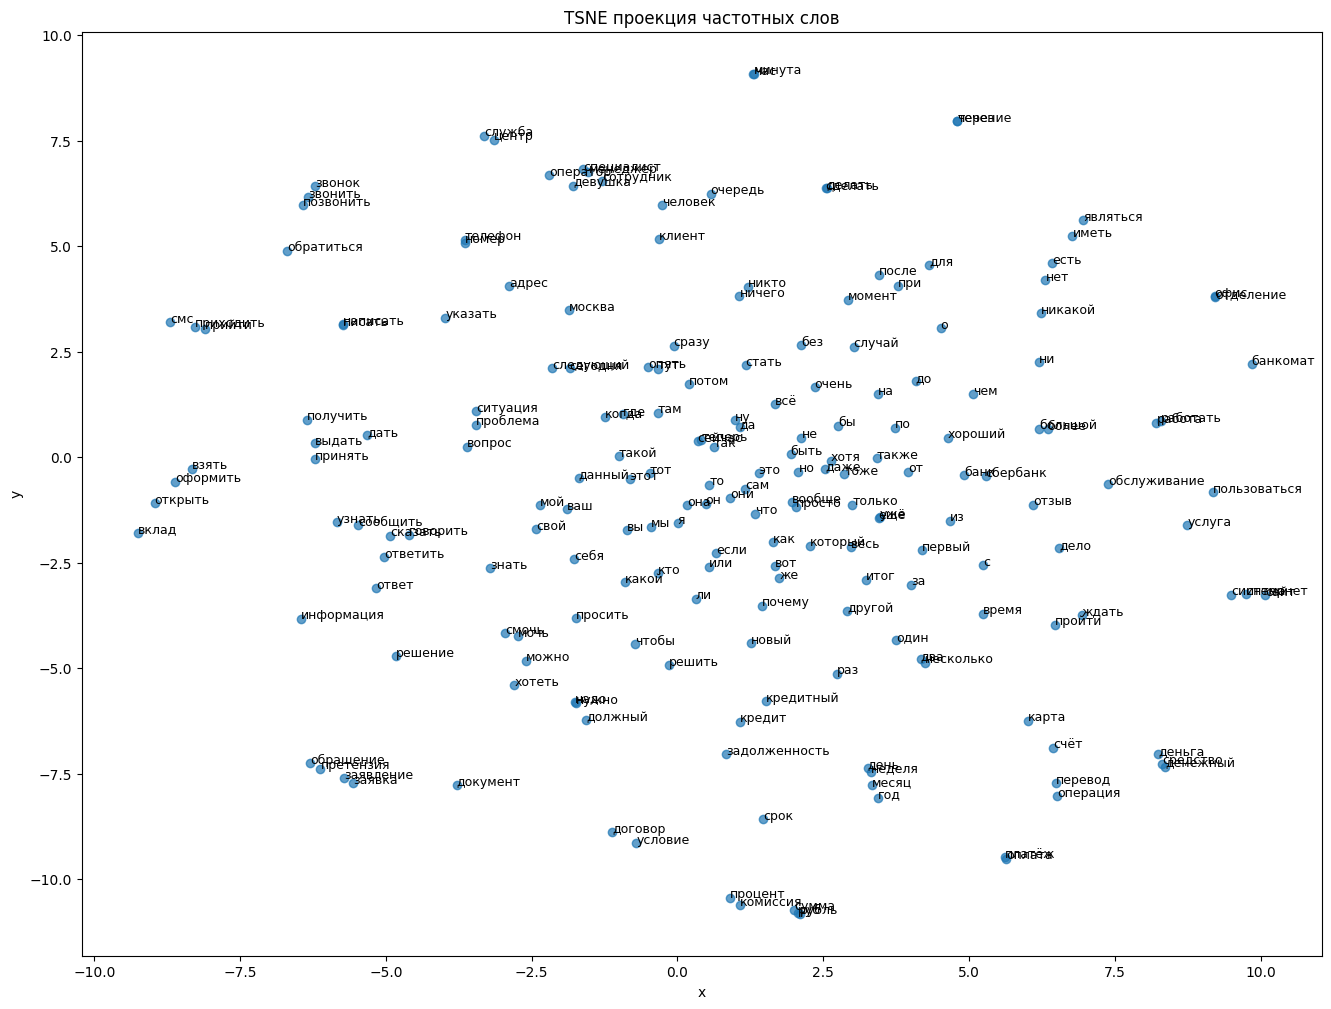

In [15]:
plt.figure(figsize=(16, 12))
plt.scatter(tsne_df['x'], tsne_df['y'], alpha=0.7)

for _, row in tsne_df.iterrows():
    plt.text(row['x'], row['y'], row['word'], fontsize=9)

plt.title('TSNE проекция частотных слов')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Рассмотрим группы слов, которые видны визуально. Например, рядом находятся слова, связанные с картами, счетами, переводами, операциями, денежными средствами.

## Визуализация 2. Координаты банков в новом пространстве

Построим двумерное пространство вручную:
- первая ось: `'плохо'` → `'хорошо'`
- вторая ось: `'медленно'` → `'быстро'`

Для этого вычисляем разностные векторы и проектируем на них названия банков.

In [16]:
def axis_vector(negative_word, positive_word):
    return model.wv[positive_word] - model.wv[negative_word]

def project_word(word, axis):
    vector = model.wv[word]
    axis_norm = np.linalg.norm(axis)
    if axis_norm == 0:
        return np.nan
    return np.dot(vector, axis) / axis_norm

quality_axis = axis_vector('плохо', 'хорошо')
speed_axis = axis_vector('медленно', 'быстро')

In [17]:
candidate_banks = df['bank_name'].dropna().astype(str).str.lower().value_counts().head(30).index.tolist()

bank_words = [bank for bank in candidate_banks if bank in model.wv]

bank_projection = pd.DataFrame({
    'bank': bank_words,
    'quality': [project_word(bank, quality_axis) for bank in bank_words],
    'speed': [project_word(bank, speed_axis) for bank in bank_words]
})

bank_projection.sort_values('quality', ascending=False).head(10)

,bank,quality,speed
2,авангард,0.397225,0.388532
3,промсвязьбанк,0.297560,0.090957
1,ситибанк,0.289423,0.164198
6,уралсиб,0.260522,0.112304
5,бинбанк,0.255129,0.022360
4,росбанк,0.221350,0.086858
0,райффайзенбанк,0.207969,0.205878


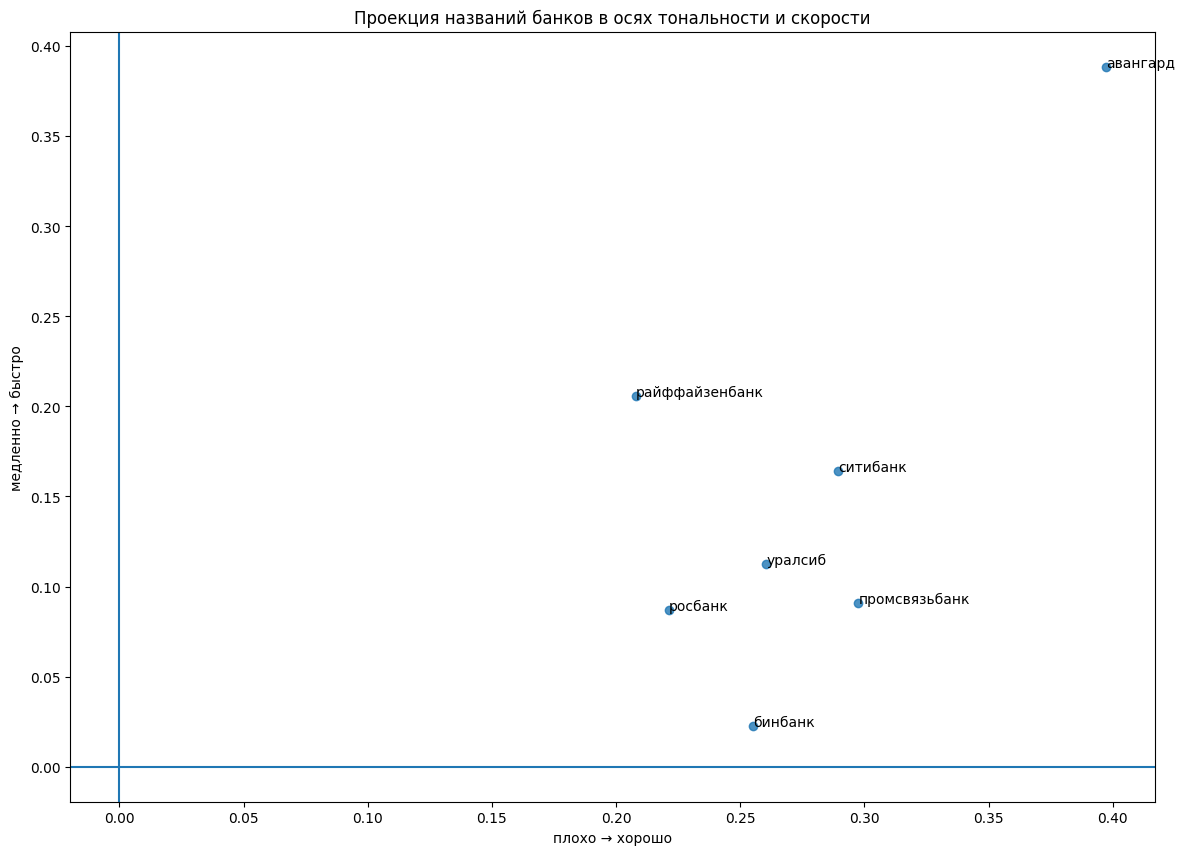

In [18]:
plt.figure(figsize=(14, 10))
plt.scatter(bank_projection['quality'], bank_projection['speed'], alpha=0.8)

for _, row in bank_projection.iterrows():
    plt.text(row['quality'], row['speed'], row['bank'], fontsize=10)

plt.axhline(0)
plt.axvline(0)
plt.title('Проекция названий банков в осях тональности и скорости')
plt.xlabel('плохо → хорошо')
plt.ylabel('медленно → быстро')
plt.show()

Ограничение метода: если название банка встречается в наборе редко или употребляется в разных контекстах. Тем не менее такая визуализация даёт качественную картину.

# Часть 2. Распространение меток

Теперь расширим словарь тональности автоматически. Для этого:
1. выбираем стартовые позитивные и негативные слова
2. строим граф или матрицу похожести слов
3. запускаем алгоритм распространения меток
4. получаем новые слова с метками `1` и `-1`

## Выбор стартовых слов

Ниже приведён набор слов, достаточно понятный в банковской предметной области.

In [19]:
positive_seeds = ['удобный', 'быстрый', 'выгодный', 'вежливый', 'надёжный', 'понятный', 'качественный']
negative_seeds = ['очередь', 'медленно', 'ошибка', 'проблема', 'обман', 'долго', 'хамство']

positive_seeds = [word for word in positive_seeds if word in model.wv]
negative_seeds = [word for word in negative_seeds if word in model.wv]

positive_seeds, negative_seeds

(['удобный',
  'быстрый',
  'выгодный',
  'вежливый',
  'надёжный',
  'понятный',
  'качественный'],
 ['очередь', 'медленно', 'ошибка', 'проблема', 'обман', 'долго', 'хамство'])

## Подготовка словаря и матрицы признаков

Берём наиболее частотные слова из модели, чтобы не строить граф по слишком большому словарю. Каждое слово представлено своим вектором `word2vec`.

In [20]:
vocab_words = [
    word for word, count in word_counts.most_common(5000)
    if word in model.wv and count >= 15
]

X = np.array([model.wv[word] for word in vocab_words])

labels = np.full(len(vocab_words), -1)

word_to_idx = {word: idx for idx, word in enumerate(vocab_words)}

for word in positive_seeds:
    if word in word_to_idx:
        labels[word_to_idx[word]] = 1

for word in negative_seeds:
    if word in word_to_idx:
        labels[word_to_idx[word]] = 0

(len(vocab_words), np.sum(labels == 1), np.sum(labels == 0), np.sum(labels == -1))

(5000, 7, 7, 4986)

Здесь используется соглашение `LabelSpreading`:
- `1` соответствует позитивному классу
- `0` соответствует негативному классу
- `-1` означает отсутствие метки

После обучения преобразуем результаты в формат, где позитивные слова будут иметь метку `1`, а негативные `-1`.

## Запуск `LabelSpreading`

Алгоритм распространит метки с размеченных слов на близкие по эмбеддингам слова.

In [21]:
label_model = LabelSpreading(kernel='rbf', gamma=0.7, max_iter=100, alpha=0.2)
label_model.fit(X, labels)

predicted = label_model.transduction_
distributions = label_model.label_distributions_

predicted[:10]

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0])

## Извлечение новых позитивных и негативных слов

Определим слова, которые не входили в исходный набор, но получили высокую оценку по одному из классов.

In [22]:
result_df = pd.DataFrame({
    'word': vocab_words,
    'predicted_class': predicted,
    'negative_score': distributions[:, 0],
    'positive_score': distributions[:, 1]
})

seed_words = set(positive_seeds + negative_seeds)
result_df = result_df[~result_df['word'].isin(seed_words)].copy()

positive_words = (
    result_df[result_df['predicted_class'] == 1]
    .sort_values('positive_score', ascending=False)
    .head(30)
)

negative_words = (
    result_df[result_df['predicted_class'] == 0]
    .sort_values('negative_score', ascending=False)
    .head(30)
)

positive_words.head(15)

,word,predicted_class,negative_score,positive_score
2323,привлекательный,1,0.001069,0.998931
4029,безопасный,1,0.002924,0.997076
4415,заманчивый,1,0.003136,0.996864
3784,оптимальный,1,0.003382,0.996618
3837,комфортный,1,0.004988,0.995012
2639,расположение,1,0.005192,0.994808
1746,приветливый,1,0.005562,0.994438
3108,ясный,1,0.005857,0.994143
4887,информативный,1,0.006128,0.993872
1645,оперативный,1,0.006337,0.993663


In [23]:
negative_words.head(15)

,word,predicted_class,negative_score,positive_score
3140,наглость,0,0.999213,0.000787
3599,грубость,0,0.999015,0.000985
3047,оскорбление,0,0.998630,0.001370
3131,ложь,0,0.998516,0.001484
503,сбой,0,0.998356,0.001644
3286,откровенный,0,0.998211,0.001789
2883,вымогательство,0,0.998169,0.001831
4352,отсидеть,0,0.998163,0.001837
1297,талон,0,0.998057,0.001943
3385,неисправность,0,0.997869,0.002131


## Финальный оценочный словарь

Преобразуем результаты в нужный формат:
- позитивные слова получают метку `1`
- негативные слова получают метку `-1`

In [24]:
positive_lexicon = positive_words[['word', 'positive_score']].copy()
positive_lexicon['label'] = 1
positive_lexicon = positive_lexicon[['word', 'label', 'positive_score']]

negative_lexicon = negative_words[['word', 'negative_score']].copy()
negative_lexicon['label'] = -1
negative_lexicon = negative_lexicon[['word', 'label', 'negative_score']]

positive_lexicon.head(15), negative_lexicon.head(15)

(                  word  label  positive_score
 2323   привлекательный      1        0.998931
 4029        безопасный      1        0.997076
 4415        заманчивый      1        0.996864
 3784       оптимальный      1        0.996618
 3837        комфортный      1        0.995012
 2639      расположение      1        0.994808
 1746       приветливый      1        0.994438
 3108             ясный      1        0.994143
 4887     информативный      1        0.993872
 1645       оперативный      1        0.993663
 2614        приемлемый      1        0.993441
 3712       дружелюбный      1        0.993269
 2641          наиболее      1        0.992983
 1796  доброжелательный      1        0.992911
 3748   доброжелательно      1        0.992894,
                 word  label  negative_score
 3140        наглость     -1        0.999213
 3599        грубость     -1        0.999015
 3047     оскорбление     -1        0.998630
 3131            ложь     -1        0.998516
 503             сбой 

## Вывод

В этом задании:
- отзывы были разбиты на предложения
- слова были лемматизированы
- обучена модель `word2vec`
- проверены стандартные тесты для эмбеддингов
- построены две визуализации
- на основе стартовых позитивных и негативных слов выполнено распространение меток
- получены новые доменно-специфические слова тональности для банковских отзывов